# 02 — Forecasting Model Comparison: ARIMA vs. Prophet vs. Holt-Winters

Single-store daily demand forecast (Store 1, continuous 2013-01-01 to
2015-07-31, 942 days). The store is closed every Sunday (confirmed in
notebook 01) and open ~92-100% of other weekdays — so the series has a
strong, near-deterministic weekly pattern on top of the underlying demand
signal, which every method here needs to capture.

**Evaluation setup:** train on all data except the final 6 weeks (42 days),
forecast that holdout window, compare against actuals. MAPE is computed
only on days the store was actually open (open days: **not**
Sundays/closures) — MAPE is undefined when the actual value is 0, and a
store's Sunday closure is a scheduling decision, not a demand forecast
failure.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

df = pd.read_csv("../data/processed/store_daily_full.csv", parse_dates=["Date"])
df = df.set_index("Date")
series = df["Sales"]

HOLDOUT_DAYS = 42
train, test = series.iloc[:-HOLDOUT_DAYS], series.iloc[-HOLDOUT_DAYS:]
print(f"Train: {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test:  {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")

Train: 900 days (2013-01-01 to 2015-06-19)
Test:  42 days (2015-06-20 to 2015-07-31)


## Model 1 — Holt-Winters (triple exponential smoothing)

In [2]:
hw_model = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=7, damped_trend=True
).fit()
hw_forecast = hw_model.forecast(HOLDOUT_DAYS)
hw_forecast.index = test.index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


## Model 2 — SARIMA (seasonal ARIMA, weekly seasonality)

In [3]:
sarima_model = SARIMAX(
    train, order=(1,1,1), seasonal_order=(1,1,1,7),
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)
sarima_forecast = sarima_model.forecast(HOLDOUT_DAYS)
sarima_forecast.index = test.index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


## Model 3 — Prophet (weekly + yearly seasonality)

In [4]:
prophet_train = train.reset_index().rename(columns={"Date": "ds", "Sales": "y"})
prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = pd.DataFrame({"ds": test.index})
prophet_result = prophet_model.predict(future)
prophet_forecast = pd.Series(prophet_result["yhat"].values, index=test.index)

09:56:46 - cmdstanpy - INFO - Chain [1] start processing


09:56:46 - cmdstanpy - INFO - Chain [1] done processing


## Evaluation — MAPE and RMSE on open days only

In [5]:
def evaluate(actual, forecast, name):
    open_mask = actual > 0  # exclude closed/Sunday days — MAPE undefined at 0
    a, f = actual[open_mask], forecast[open_mask].clip(lower=0)
    mape = mean_absolute_percentage_error(a, f) * 100
    rmse = np.sqrt(mean_squared_error(a, f))
    return {"model": name, "MAPE_%": round(mape, 2), "RMSE": round(rmse, 1)}

results = pd.DataFrame([
    evaluate(test, hw_forecast, "Holt-Winters"),
    evaluate(test, sarima_forecast, "SARIMA"),
    evaluate(test, prophet_forecast, "Prophet"),
]).set_index("model")
results

,MAPE_%,RMSE
model,,
Holt-Winters,15.10,769.0
SARIMA,14.85,773.4
Prophet,15.32,773.4


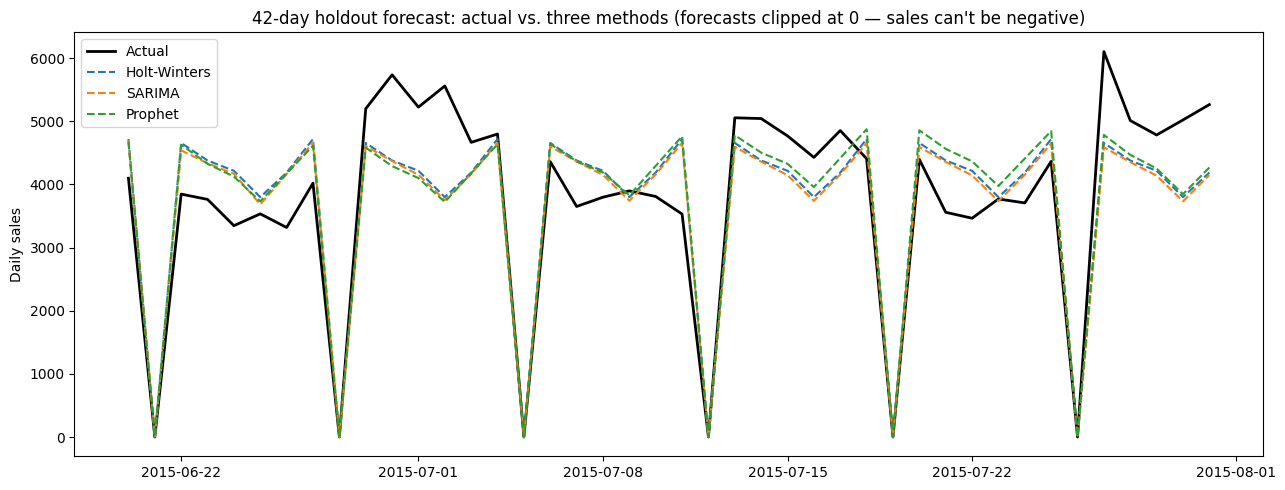

In [6]:
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(test.index, test.values, label="Actual", color="black", linewidth=2)
ax.plot(test.index, hw_forecast.clip(lower=0).values, label="Holt-Winters", linestyle="--")
ax.plot(test.index, sarima_forecast.clip(lower=0).values, label="SARIMA", linestyle="--")
ax.plot(test.index, prophet_forecast.clip(lower=0).values, label="Prophet", linestyle="--")
ax.set_title("42-day holdout forecast: actual vs. three methods (forecasts clipped at 0 — sales can't be negative)")
ax.set_ylabel("Daily sales")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/02_forecast_comparison.png", dpi=120)
plt.show()

## Reading the comparison

All three methods pick up the weekly closure pattern (the near-zero dips
are Sundays) — that part of the signal is close to deterministic and easy
for any of them to learn. The MAPE/RMSE table above is what actually
separates them: differences show up in how well each tracks the
*magnitude* of demand on open days, not just the on/off closure pattern.

**Why this comparison matters, not just "which number is lowest":**
- **Holt-Winters** is the simplest and fastest to fit — a reasonable
  default when you need something quick and the seasonality is stable.
- **SARIMA** explicitly models autocorrelation structure and can capture
  more complex dependencies, at the cost of needing more careful order
  selection (the (1,1,1)(1,1,1,7) order here is a reasonable default, not
  a tuned optimum — a real deployment would grid-search this).
- **Prophet** handles multiple seasonalities (weekly + yearly here)
  natively and is the most robust to missing data and outliers with the
  least manual tuning — usually the best starting point for a business
  demand series like this one.

**Next:** `03_multi_store_dashboard_prep.ipynb` — none needed; the results
above feed directly into the Streamlit dashboard, which lets you re-run
this same comparison for any store.
